In [ ]:
import pandas as pd
from tqdm import tqdm
from datasets import Dataset, DatasetDict, load_dataset
from huggingface_hub import login
from collections import Counter

# Relative import
import sys
import os
# Get the parent directory of the notebook (project root)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.utils import show_examples, plot_distribution, investigate_patterns


tqdm.pandas() 
login(token="")


In [23]:
ds = load_dataset("mteb/tweet_sentiment_extraction",trust_remote_code=True)
ds

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 26732
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 3432
    })
})

In [24]:
# Convert datasets to DataFrames
df1 = ds["train"].to_pandas()
df1["split"] = "train"

df2 = ds["test"].to_pandas()
df2["split"] = "test"

# Concatenate all splits
df = pd.concat([df1, df2], ignore_index=True)
df = df.rename(columns={"id": "text_id"})
df.head()

,text_id,text,label,label_text,split
0,cb774db0d1,"I`d have responded, if I were going",1,neutral,train
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,0,negative,train
2,088c60f138,my boss is bullying me...,0,negative,train
3,9642c003ef,what interview! leave me alone,0,negative,train
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...",0,negative,train


In [25]:
investigate_patterns(df,text_column="text",n_examples=3)

Investigating HTTP...
Occurrence of pattern: 1393
That's 4.62% of messages

Showing 3 example(s) for pattern: HTTP
  1: Good morning world!  haha had fun at the movies last night ;D and school now... Hmm new shoes make it better  http://tinyurl.com/dfggwj
  2: will sleep in a while. still mourning the adobo he cooked.  http://plurk.com/p/x12gf
  3:  Thanks for the follow. I`m loving the energy on your site. The spaz in me can`t help but be drawn to you  http://www.ted.me/

-----------------
Investigating DOMAINS...
Occurrence of pattern: 338
That's 1.12% of messages

Showing 3 example(s) for pattern: DOMAINS
  1: Awww the boys have no beards?    I LIKED THEIR MANLY MAN-NESS [via ] #asylm
  2: just 3 days left for the offf 2009 http://www.offf.ws/ in oeiras portugal... see you there
  3: 2,697 views on my FLickr Account.. Maybe is not much for you...  but I`m happy  ... YAY http://www.flickr.com/photos/bonassin/

-----------------
Investigating BITLY URL...
Occurrence of pattern: 195
Th

# Preprocess

In [26]:
# def preprocess_senti(text):

#     text = re.sub(r'https?://\S+', '', text) # remove remaining links
#     text = re.sub(r"https?://[A-Za-z0-9./]+", "", text)  # remove links
#     text = re.sub(r"@[A-Za-z0-9_]+", "@user", text)  # replace user mentions with @user
#     text = re.sub(r"bit.ly/\S+","",text) # remove bit.ly url
#     text = re.sub(r"www\.[^\s.]+\.[^\s]+","",text) # remove bdomains

#     # Formatting:
#     text = re.sub("\t", " ", text)  # remove tab
#     text = re.sub("\n", " ", text)  # remove newlines
#     text = re.sub("\r", " ", text)  # remove \r type newlines
#     text = re.sub(r" +", " ", text)  # remove multiple whitespaces
#     text = re.sub(r"linebreak", "", text)  # remove linebreaks
    
#     text = text.strip() # Remove leading whitespace
#     return text

In [27]:
# # Preprocess text
# df["text"] = df["text"].progress_apply(preprocess_senti)

# Convert labels to text
id2text = {0: "negative", 1: "neutral", 2: "positive"}
df["label_text"] = df["label"].apply(lambda x: id2text[x])


### Evaluate processed DS

In [28]:
# Check processing worked as intended
investigate_patterns(df,text_column="text",n_examples=3)

Investigating HTTP...
Occurrence of pattern: 1393
That's 4.62% of messages

Showing 3 example(s) for pattern: HTTP
  1: my portfolio v2 uploaded! any comments and feedback are warmly welcomed!  http://www.maxiin.net/
  2: Just listened to condre scr and got an invitation to watch their live concert on June 20th in Munich http://bit.ly/DAXA0  #postrock
  3: A gift to myself. PUBLISHED! Episode 68 Align and Re-Align with Sensitivity Level 1-2 75 min #yoga class  http://bit.ly/8QAgh

-----------------
Investigating DOMAINS...
Occurrence of pattern: 338
That's 1.12% of messages

Showing 3 example(s) for pattern: DOMAINS
  1: aaawww im soooOOooo tired today.. i dont feel good.. i dont wanna go to work wah..  but yeah im goin to work in a few mins. til closing..
  2: Listening to some house music!(what else?) I got a gig in San Francisco next Friday. BE THERE  details on my www.myspace.com/djspy
  3:   awwww i have no internet right now....  -drummer boi

-----------------
Investigating BITL

Label counts:
 label_text
neutral     12073
positive     9440
negative     8651
Name: count, dtype: int64


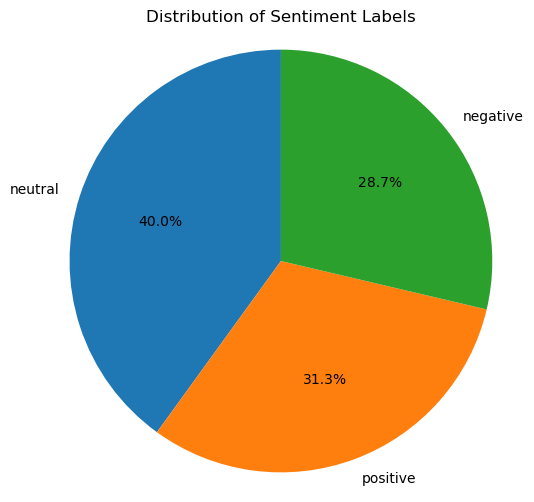


Showing 3 example(s) for label: neutral
  1: just sending a twitter from the club! i twittered u
  2: _127 LOL Just remember how it was after my car accident
  3:  yeah but i missed it 2nite

Showing 3 example(s) for label: negative
  1: Panera is not being nice to my iPhone
  2: i had a new friend who called himself shame.
  3: grrh  wii remote dead.. no multiplayer here tonight

Showing 3 example(s) for label: positive
  1: Ohhh  only a bit of time left to have an account on the forums.. I do hope I get to be a leader some day :/
  2: WHOA! Twilight the board game! AAAHAHA
  3:  I`ve given the $19.99 question more thought. U may be right. One host provides HD quality to all viewers? Maybe not.


In [29]:
plot_distribution(df, label_column="label_text", class_name="Sentiment")
show_examples(df, label_column="label_text")

### Prepare DatasetDict

In [30]:
# Adjust split to 80/10/10
print("Test:", len(df2) / len(df))
print("Train:", len(df1) / len(df))
#df = df.drop("split", axis=1)
df.head()

Test: 0.11377801352605756
Train: 0.8862219864739425


,text_id,text,label,label_text,split
0,cb774db0d1,"I`d have responded, if I were going",1,neutral,train
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,0,negative,train
2,088c60f138,my boss is bullying me...,0,negative,train
3,9642c003ef,what interview! leave me alone,0,negative,train
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...",0,negative,train


In [31]:
dd_final = DatasetDict(
    {"train": Dataset.from_pandas(df[df.split == "train"].drop(columns="split"), preserve_index=False).shuffle(seed=42),
     "test": Dataset.from_pandas(df[df.split == "test"].drop(columns="split"), preserve_index=False).shuffle(seed=42),
})

dd_final

DatasetDict({
    train: Dataset({
        features: ['text_id', 'text', 'label', 'label_text'],
        num_rows: 26732
    })
    test: Dataset({
        features: ['text_id', 'text', 'label', 'label_text'],
        num_rows: 3432
    })
})

In [32]:
# ds_pos = Dataset.from_pandas(df[df.label_text == "positive"],preserve_index=False).shuffle(seed=42)
# ds_neu = Dataset.from_pandas(df[df.label_text == "neutral"],preserve_index=False).shuffle(seed=42)
# ds_neg = Dataset.from_pandas(df[df.label_text == "negative"],preserve_index=False).shuffle(seed=42)

# def split_ds_to_dataset_dict(dataset):
#     train_testvalid = dataset.train_test_split(test_size=0.2, seed=42)
#     test_valid = train_testvalid['test'].train_test_split(test_size=0.5, seed=42)
#     # # Combine into DatasetDict
#     dataset_dict = DatasetDict({
#         'train': train_testvalid['train'],
#         'validation': test_valid['train'],
#         'test': test_valid['test']
#     })
#     return dataset_dict

# dd_pos = split_ds_to_dataset_dict(ds_pos)
# dd_neu = split_ds_to_dataset_dict(ds_neu)
# dd_neg = split_ds_to_dataset_dict(ds_neg)

# dd_final = DatasetDict({
#     "train": concatenate_datasets([dd_pos["train"], dd_neu["train"], dd_neg["train"]]).shuffle(seed=42),
#     "validation": concatenate_datasets([dd_pos["validation"], dd_neu["validation"], dd_neg["validation"]]).shuffle(seed=42),
#     "test": concatenate_datasets([dd_pos["test"], dd_neu["test"], dd_neg["test"]]).shuffle(seed=42)
#     })

# dd_final

In [33]:
# Inspect distributions
for k, v in dd_final.items():
    print(f"=== {k} ===")
    counts = Counter(v["label_text"])
    total = sum(counts.values())
    
    for label, count in counts.items():
        percent = (count / total) * 100
        print(f"{label}: {count} ({percent:.2f}%)")
    
    print()


=== train ===
neutral: 10698 (40.02%)
negative: 7668 (28.68%)
positive: 8366 (31.30%)

=== test ===
positive: 1074 (31.29%)
neutral: 1375 (40.06%)
negative: 983 (28.64%)



### Upload to HF

In [34]:
dd_final.push_to_hub("TomData/sentiment_extraction", private=True)

Creating parquet from Arrow format: 100%|██████████| 27/27 [00:02<00:00, 12.82ba/s]
Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
Creating parquet from Arrow format: 100%|██████████| 4/4 [00:00<00:00, 11.30ba/s]
Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
Uploading the dataset shards: 100%|██████████| 1/1 [00:02<00:00,  2.70s/it]
c:\Users\tomkl\.conda\envs\ds_process\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tomkl\.cache\huggingface\hub\datasets--TomData--sentiment_extraction. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggin

CommitInfo(commit_url='https://huggingface.co/datasets/TomData/sentiment_extraction/commit/ad2e78c3e87ff10f23bd4850dcd0795f9cb99e5b', commit_message='Upload dataset', commit_description='', oid='ad2e78c3e87ff10f23bd4850dcd0795f9cb99e5b', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/TomData/sentiment_extraction', endpoint='https://huggingface.co', repo_type='dataset', repo_id='TomData/sentiment_extraction'), pr_revision=None, pr_num=None)